<a href="https://colab.research.google.com/github/CarolaineRangel/Chamados-no-Suporte-por-Faixa-de-Faturamento/blob/main/Motivos_de_chamado_do_suporte_com_a_faixa_de_faturamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kmodes
! pip install google-cloud-bigquery
!pip install scipy
!pip install prince
! pip install adjustText

from google.colab import auth
auth.authenticate_user()
print('Authenticated')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.8/417.8 kB 6.3 MB/s eta 0:00:00
Authenticated


In [ ]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kprototypes import KPrototypes

project_id = 'name_projeto'

client = bigquery.Client(project=project_id)

query = """ with ticket_base as (
  select
    distinct
    coalesce(a.installation_id, 0) as installation_id,
    coalesce(ticket_n1_model, '0') as ticket_n1_model,
    coalesce(ticket_n2_area, '0') as ticket_n2_area,
    coalesce(ticket_n3_conclusion, '0') as ticket_n3_conclusion,
    a.created_at,
    c.last_won_date
  from `freshworks.freshdesk_tickets` a
  left join `hubspot.hubspot_companies` c on a.installation_id = c.idi_app
  where c.idi_app is not null and c.last_won_date is not null and ticket_n1_model is not null
),

gmv_until_ticket as (
  select
    mta.installation_id,
   saled_date as saled_month,
    sum(mta.month_gmv) as gmv_month
  from `finance.monthly_transactions_amount` mta
  group by mta.installation_id, saled_month
), final as (

select
distinct
  tb.installation_id,
  tb.ticket_n1_model,
  tb.ticket_n2_area,
  tb.ticket_n3_conclusion,
  tb.created_at,
  tb.last_won_date,
  date_diff (last_won_date, date (created_at), month) as tempo_won_para_chamado_month,
  (    select sum(g.gmv_month)
    from gmv_until_ticket g
    where g.installation_id = tb.installation_id
      and g.saled_month <= format_date('%Y-%m', tb.created_at))
   as total_gmv_until_ticket

from ticket_base tb
where  date_diff (last_won_date, date (created_at), month) >= 0
)

select
distinct
coalesce (installation_id, 0) as installation_id,
coalesce (ticket_n1_model, '0') as ticket_n1_model,
coalesce (ticket_n2_area, '0') as ticket_n2_area,
coalesce (ticket_n3_conclusion, '0') as  ticket_n3_conclusion,
CASE WHEN total_gmv_until_ticket >= 0 AND total_gmv_until_ticket < 5000 THEN 'A. 0 a 5k'
        WHEN total_gmv_until_ticket >= 5000 AND total_gmv_until_ticket < 10000 THEN 'B. 5 a 10k'
        WHEN total_gmv_until_ticket >= 10000 AND total_gmv_until_ticket < 15000 THEN 'C. 10 a 15k'
        WHEN total_gmv_until_ticket >= 15000 AND total_gmv_until_ticket < 20000 THEN 'D. 15 a 20k'
        WHEN total_gmv_until_ticket >= 20000 AND total_gmv_until_ticket < 25000 THEN 'E. 20 a 25k'
        WHEN total_gmv_until_ticket >= 25000 AND total_gmv_until_ticket < 30000 THEN 'F. 25 a 30k'
        WHEN total_gmv_until_ticket >= 30000 AND total_gmv_until_ticket < 50000 THEN 'G. 30 a 50k'
        WHEN total_gmv_until_ticket >= 50000 AND total_gmv_until_ticket < 80000 THEN 'H. 50 a 80k'
        WHEN total_gmv_until_ticket >= 80000 AND total_gmv_until_ticket < 100000 THEN 'I. 80 a 100k'
        WHEN total_gmv_until_ticket >= 100000 AND total_gmv_until_ticket < 150000 THEN 'J. 100 a 150k'
        WHEN total_gmv_until_ticket >= 150000 AND total_gmv_until_ticket < 200000 THEN 'K. 150 a 200k'
        WHEN total_gmv_until_ticket >= 200000 AND total_gmv_until_ticket < 250000 THEN 'L. 200 a 250k'
        WHEN total_gmv_until_ticket >= 250000 AND total_gmv_until_ticket < 400000 THEN 'M. 250 a 400k'
        WHEN total_gmv_until_ticket >= 400000 THEN 'N. 400k+'
         ELSE 'sem vendas'
    END AS faixa_faturamento,
tempo_won_para_chamado_month,
case when tempo_won_para_chamado_month >=0 and tempo_won_para_chamado_month <= 2 then 'A. 0 a 2 meses'
when tempo_won_para_chamado_month >=3 and tempo_won_para_chamado_month <= 5 then 'B. 3 a 5 meses'
when tempo_won_para_chamado_month >=6 and tempo_won_para_chamado_month <= 10 then 'C. 6 a 10 meses'
when tempo_won_para_chamado_month >=11 and tempo_won_para_chamado_month <= 20 then 'D. 11 a 20 meses'
when tempo_won_para_chamado_month >=21 and tempo_won_para_chamado_month <= 30 then 'E. 21 a 30 meses'
when tempo_won_para_chamado_month >=31  then 'F. 31 meses +'
end as faixa_tempo_won_para_chamado,
coalesce (forms_monthly_revenue, '0') as forms_monthly_revenue,
from final f
left join `customer_experience.base_icp_for_analitics` bi  on bi.idi_app = f.installation_id

 """
query_job = client.query(query)
df = query_job.to_dataframe()
df.head()

,installation_id,ticket_n1_model,ticket_n2_area,ticket_n3_conclusion,faixa_faturamento,tempo_won_para_chamado_month,faixa_tempo_won_para_chamado,forms_monthly_revenue
0,38957,Chat - Cliente Ausente,0,0,N. 400k+,1,A. 0 a 2 meses,0
1,38957,Dúvida,Sem Tag,0,N. 400k+,1,A. 0 a 2 meses,0
2,38957,Solicitação,Relacionamento,0,N. 400k+,1,A. 0 a 2 meses,0
3,38957,Solicitação,Financeiro,Desbloqueio - Pagamento Realizado,N. 400k+,3,B. 3 a 5 meses,0
4,38957,Dúvida,Pagamento Online,0,N. 400k+,1,A. 0 a 2 meses,0


In [ ]:
contingency_percent = pd.crosstab(df['faixa_tempo_won_para_chamado'], df['faixa_faturamento'], normalize='index') * 100
print(contingency_percent.round(2))


pd.set_option('display.max_rows', None)
file_path = 'contingency_percent.xlsx'
contingency_percent.to_excel(file_path, index=True)

# Se estiver no Google Colab, usa este para baixar:
from google.colab import files
files.download(file_path)

faixa_faturamento             A. 0 a 5k  B. 5 a 10k  C. 10 a 15k  D. 15 a 20k  \
faixa_tempo_won_para_chamado                                                    
A. 0 a 2 meses                    29.81       12.64         8.76         6.18   
B. 3 a 5 meses                    11.32        3.41         3.36         2.64   
C. 6 a 10 meses                    8.76        4.53         2.56         2.23   
D. 11 a 20 meses                   6.10        4.29         3.90         2.96   
E. 21 a 30 meses                   7.21        8.52         1.97         5.57   

faixa_faturamento             E. 20 a 25k  F. 25 a 30k  G. 30 a 50k  \
faixa_tempo_won_para_chamado                                          
A. 0 a 2 meses                       4.52         3.67         8.64   
B. 3 a 5 meses                       1.76         1.55         4.91   
C. 6 a 10 meses                      1.00         1.30         6.75   
D. 11 a 20 meses                     2.45         1.37         5.70   
E. 21 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import scipy.stats as stats

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cramers_v_value = cramers_v(df['ticket_n1_model'], df['faixa_faturamento'])
print(f"Cramér's V entre ticket_n1_model e faixa_faturamento: {cramers_v_value:.4f}")

cramers_v_value_1 = cramers_v(df['ticket_n2_area'], df['faixa_faturamento'])
print(f"Cramér's V entre ticket_n2_area e faixa_faturamento: {cramers_v_value_1:.4f}")

cramers_v_value_2 = cramers_v(df['ticket_n3_conclusion'], df['faixa_faturamento'])
print(f"Cramér's V entre ticket_n3_conclusion e faixa_faturamento: {cramers_v_value_2:.4f}")

cramers_v_value_3 = cramers_v(df['faixa_tempo_won_para_chamado'], df['faixa_faturamento'])
print(f"Cramér's V entre faixa_tempo_won_para_chamado e faixa_faturamento: {cramers_v_value_3:.4f}")

Cramér's V entre ticket_n1_model e faixa_faturamento: 0.0814
Cramér's V entre ticket_n2_area e faixa_faturamento: 0.0906
Cramér's V entre ticket_n3_conclusion e faixa_faturamento: 0.0996
Cramér's V entre faixa_tempo_won_para_chamado e faixa_faturamento: 0.2779


In [ ]:
import pandas as pd
import numpy as np
from kmodes.kprototypes import KPrototypes
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

# Supondo que df seja o DataFrame retornado do BigQuery
# Primeiro, armazene a coluna 'company_id' em uma variável separada
company_ids = df['installation_id'].copy()

# Crie uma cópia do DataFrame para processar a clusterização
df_cluster = df.copy()

# Remova a coluna 'company_id' de df_cluster para não interferir na clusterização
df_cluster.drop(columns=['installation_id'], inplace=True, errors='ignore')

# --- Pré-processamento ---
# Corrige vírgulas e tenta converter para float (quando aplicável)
for col in df_cluster.columns:
    if df_cluster[col].dtype == 'object':
        try:
            df_cluster[col] = df_cluster[col].str.replace(',', '.').astype(float)
        except:
            continue

# Identifica colunas categóricas e preenche NaNs com "desconhecido"
categorical_cols = []
for i, col in enumerate(df_cluster.columns):
    if df_cluster[col].dtype == 'object' or df_cluster[col].dtype == bool:
        categorical_cols.append(i)
        df_cluster[col] = df_cluster[col].astype(str).fillna("desconhecido")

# Preenche colunas numéricas com a média (se houver NaNs)
for col in df_cluster.columns:
    if df_cluster[col].dtype in [np.float64, np.int64]:
        df_cluster[col] = df_cluster[col].fillna(df_cluster[col].mean())

# Verifica se não há mais NaNs
assert df_cluster.isna().sum().sum() == 0, "Ainda há valores NaN no df_cluster!"

# --- Clusterização com K-Prototypes ---
# Converte para array (todos os dados de df_cluster, que agora NÃO contém company_id)
matrix = df_cluster.to_numpy()

# Aplica o K-Prototypes
kproto = KPrototypes(n_clusters=4, init='Cao', n_init=1, verbose=1, gamma=0)
clusters = kproto.fit_predict(matrix, categorical=categorical_cols)

# --- Reassocia os clusters ao DataFrame original ---
df['Cluster'] = clusters
# Reinsere a coluna 'company_id' usando a variável armazenada
df['installation_id'] = company_ids

# --- Cria tabela com company_id e Cluster ---
tabela_cluster_por_empresa = df[['installation_id', 'Cluster']].copy()
print("\n🔍 Tabela com installation_id e Cluster:")
print(tabela_cluster_por_empresa.head())

pd.set_option('display.max_rows', None)
file_path = 'tabela_cluster_por_empresa.xlsx'
tabela_cluster_por_empresa.to_excel(file_path, index=True)

# Se estiver no Google Colab, usa este para baixar:
from google.colab import files
files.download(file_path)

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 2665, ncost: 59345.32406992054
Run: 1, iteration: 2/100, moves: 1727, ncost: 45674.309867506796
Run: 1, iteration: 3/100, moves: 829, ncost: 41931.90778816439
Run: 1, iteration: 4/100, moves: 891, ncost: 37831.75588629965
Run: 1, iteration: 5/100, moves: 112, ncost: 37769.826933564174
Run: 1, iteration: 6/100, moves: 0, ncost: 37769.826933564174

🔍 Tabela com installation_id e Cluster:
   installation_id  Cluster
0            38957        3
1            38957        3
2            38957        3
3            38957        0
4            38957        3


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

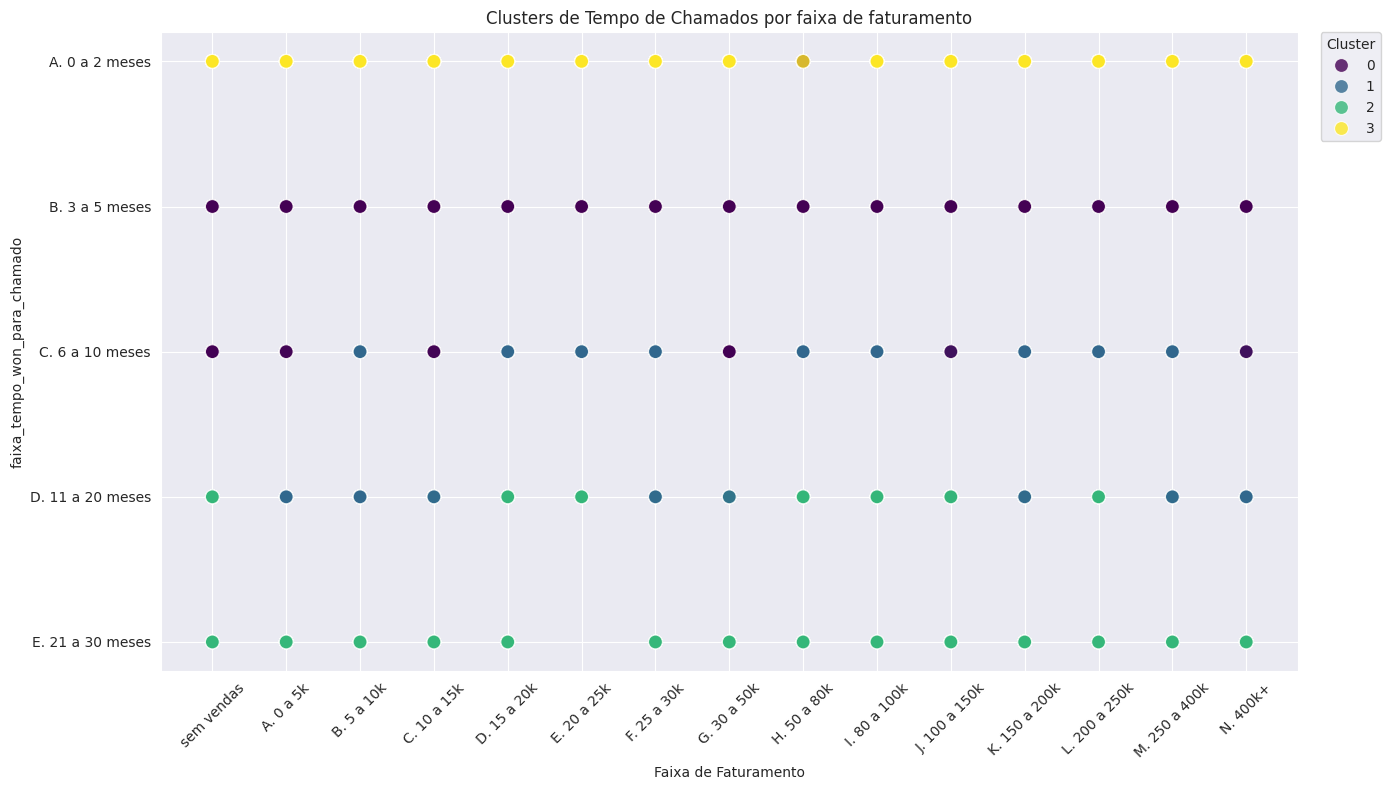

In [ ]:
ordem_faixas = [
    'sem vendas',
    'A. 0 a 5k', 'B. 5 a 10k', 'C. 10 a 15k', 'D. 15 a 20k', 'E. 20 a 25k',
    'F. 25 a 30k', 'G. 30 a 50k', 'H. 50 a 80k', 'I. 80 a 100k',
    'J. 100 a 150k', 'K. 150 a 200k', 'L. 200 a 250k', 'M. 250 a 400k', 'N. 400k+'
]

# Convertendo para tipo categórico ordenado
df['faixa_faturamento'] = pd.Categorical(df['faixa_faturamento'], categories=ordem_faixas, ordered=True)

plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df,
    x='faixa_faturamento',
    y='faixa_tempo_won_para_chamado',
    hue='Cluster',
    palette='viridis',
    alpha=0.8,
    s=100
)
plt.title('Clusters de Tempo de Chamados por faixa de faturamento')
plt.xlabel('Faixa de Faturamento')
plt.ylabel('faixa_tempo_won_para_chamado')
plt.xticks(rotation=45)
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
#plt.ylim(0, 100)  # Força o limite superior para 100 meses
plt.grid(True)
plt.tight_layout()
plt.show()

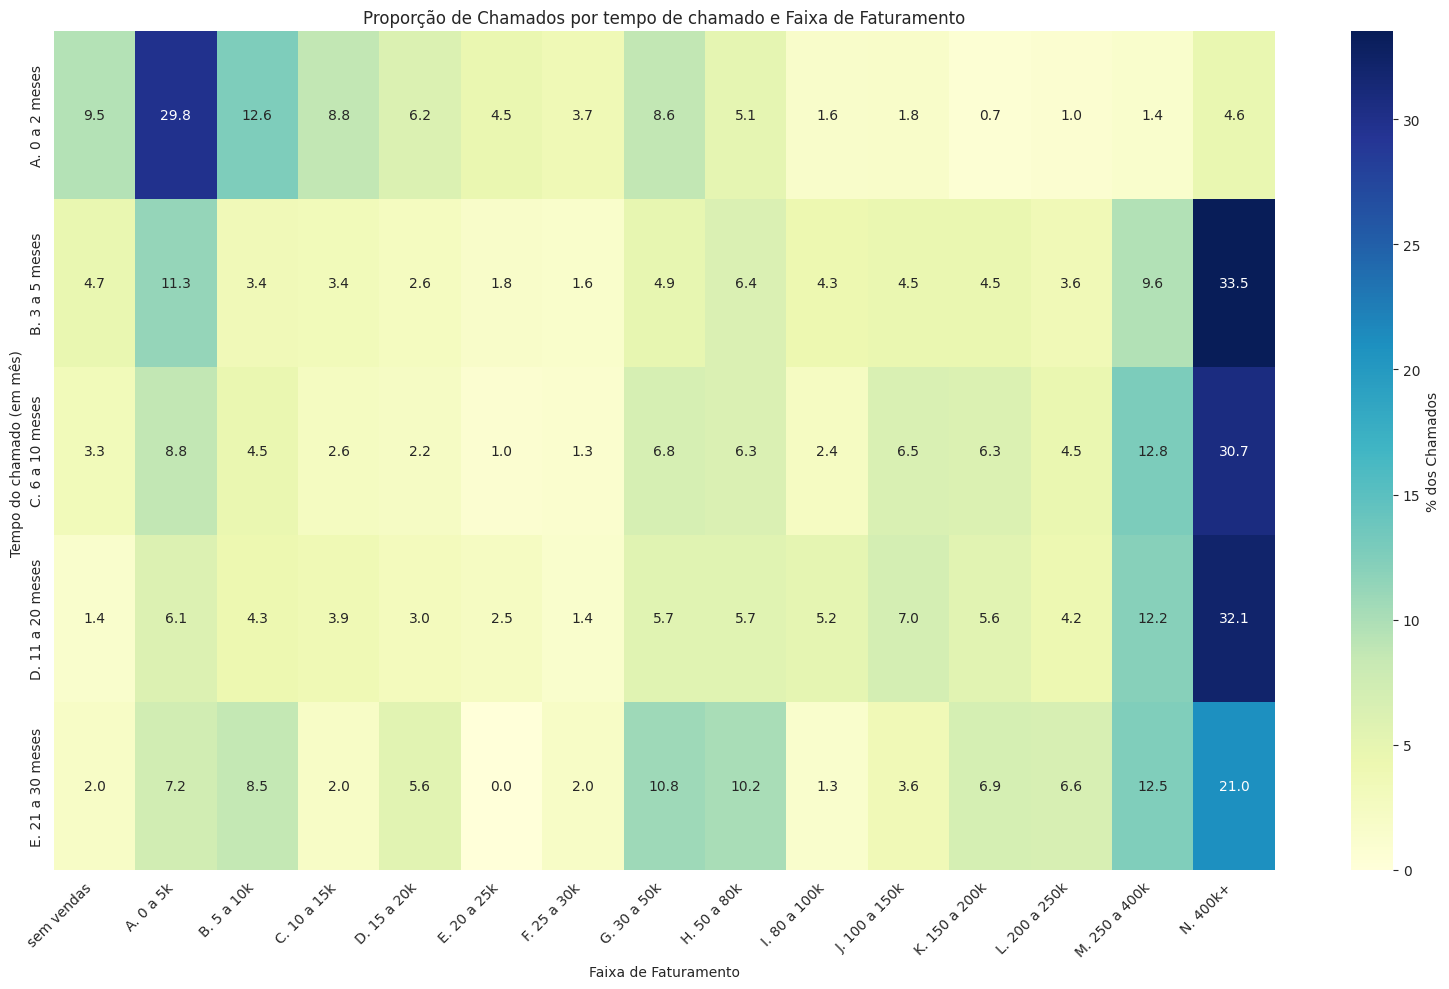

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Garante a ordem correta das faixas
ordem_faixas = [
    'sem vendas',
    'A. 0 a 5k', 'B. 5 a 10k', 'C. 10 a 15k', 'D. 15 a 20k', 'E. 20 a 25k',
    'F. 25 a 30k', 'G. 30 a 50k', 'H. 50 a 80k', 'I. 80 a 100k',
    'J. 100 a 150k', 'K. 150 a 200k', 'L. 200 a 250k', 'M. 250 a 400k', 'N. 400k+'
]
df['faixa_faturamento'] = pd.Categorical(df['faixa_faturamento'], categories=ordem_faixas, ordered=True)

# Cria a tabela de contingência com proporções (normalizando por linha)
contingency = pd.crosstab(df['faixa_tempo_won_para_chamado'], df['faixa_faturamento'], normalize='index') * 100

# Plota o heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(contingency, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': '% dos Chamados'})
plt.title('Proporção de Chamados por tempo de chamado e Faixa de Faturamento')
plt.xlabel('Faixa de Faturamento')
plt.ylabel('Tempo do chamado (em mês) ')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


<ipython-input-71-1cf641a04a5a>:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df_cluster.pivot_table(


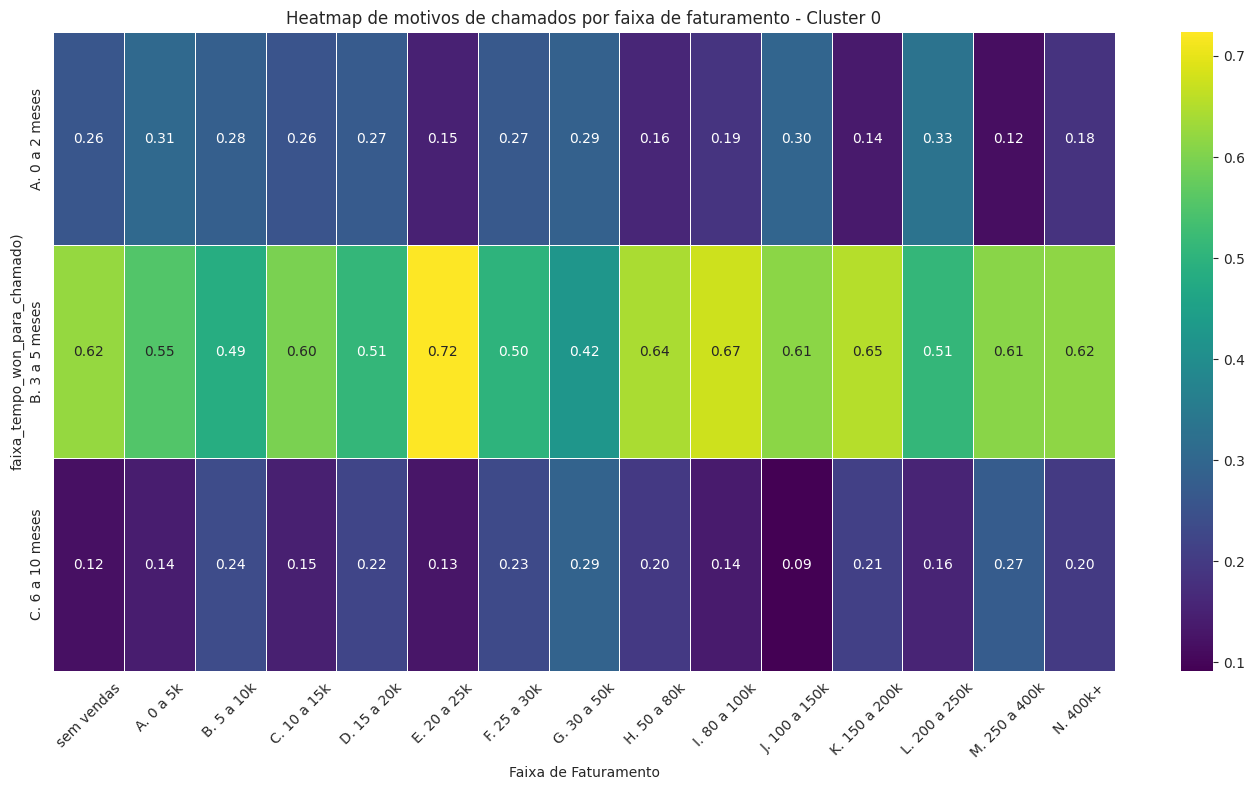

<ipython-input-71-1cf641a04a5a>:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df_cluster.pivot_table(


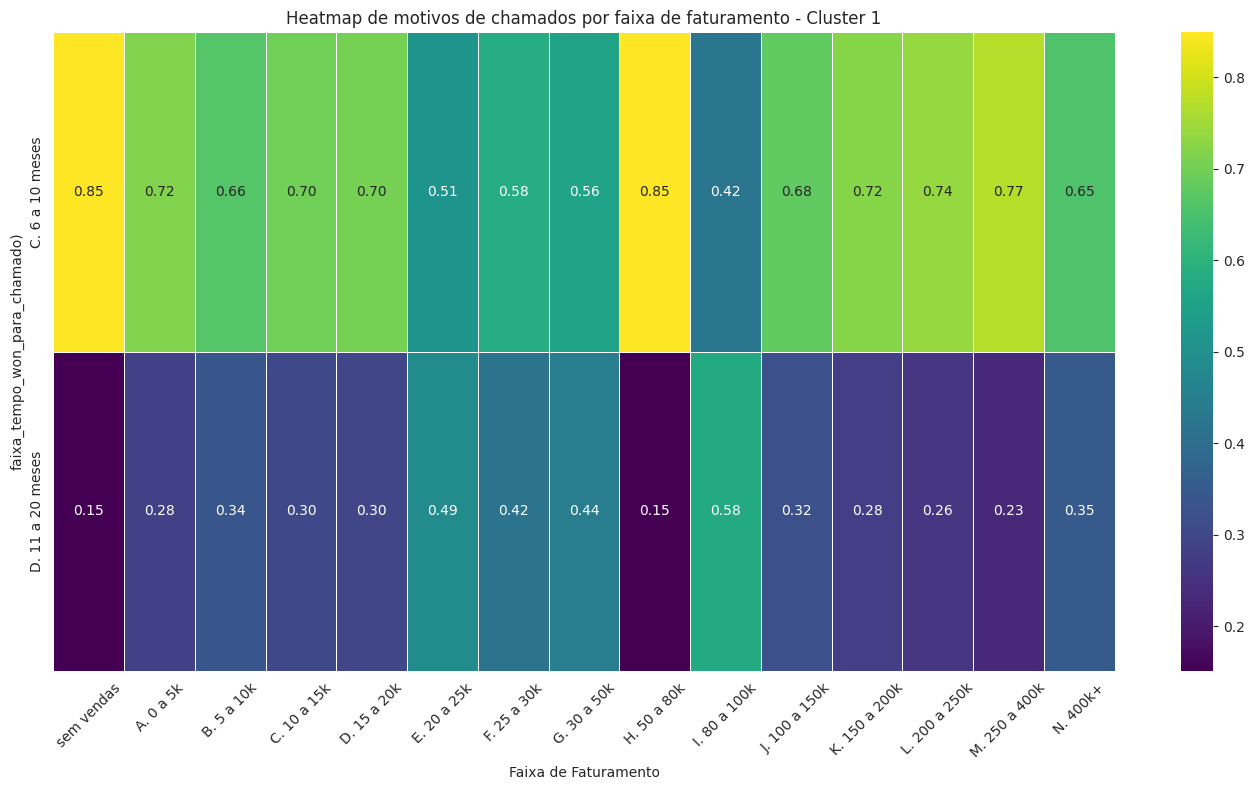

<ipython-input-71-1cf641a04a5a>:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df_cluster.pivot_table(


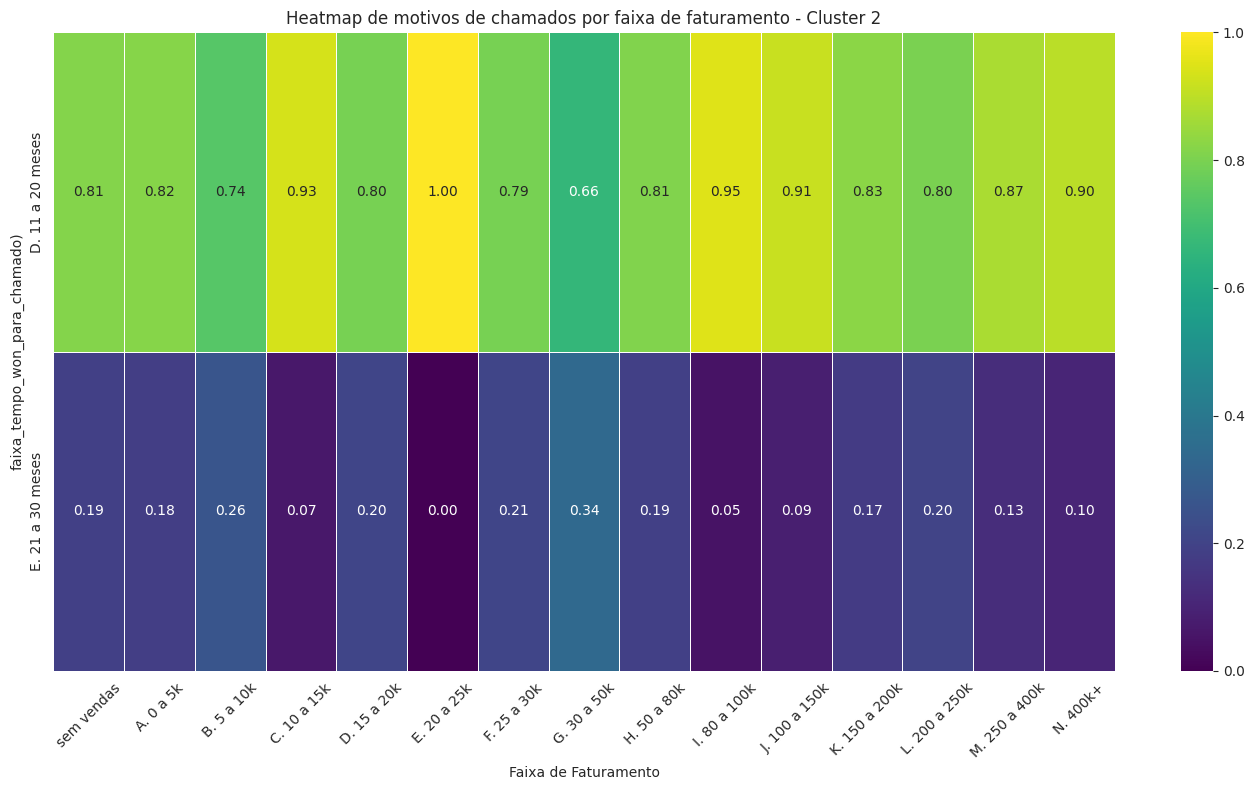

<ipython-input-71-1cf641a04a5a>:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df_cluster.pivot_table(


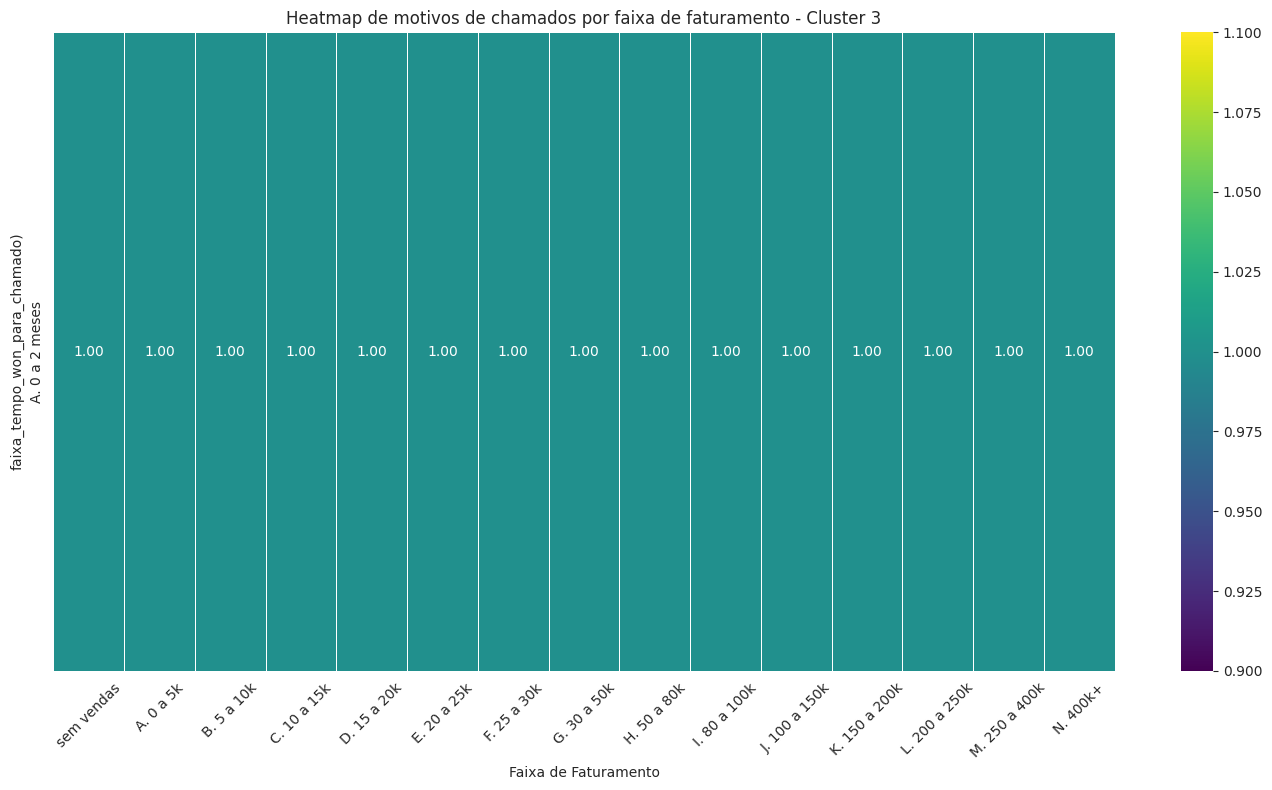

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Agrupar: contar chamados por motivo, faixa de faturamento e cluster
df_agg = df.groupby(['Cluster', 'faixa_tempo_won_para_chamado', 'faixa_faturamento'], observed=True).size().reset_index(name='qtd_chamados')

# 2. Calcular proporção dentro de cada cluster e faixa de faturamento (corrigido!)
df_agg['proporcao'] = df_agg.groupby(['Cluster', 'faixa_faturamento'], observed=True)['qtd_chamados'].transform(lambda x: x / x.sum())

# 3. Garantir a ordem correta das faixas de faturamento
ordem_faixas = [
    'sem vendas',
    'A. 0 a 5k', 'B. 5 a 10k', 'C. 10 a 15k', 'D. 15 a 20k', 'E. 20 a 25k',
    'F. 25 a 30k', 'G. 30 a 50k', 'H. 50 a 80k', 'I. 80 a 100k',
    'J. 100 a 150k', 'K. 150 a 200k', 'L. 200 a 250k', 'M. 250 a 400k', 'N. 400k+'
]
df_agg['faixa_faturamento'] = pd.Categorical(df_agg['faixa_faturamento'], categories=ordem_faixas, ordered=True)

# 4. Plotar heatmap por cluster
for cluster in sorted(df_agg['Cluster'].unique()):
    df_cluster = df_agg[df_agg['Cluster'] == cluster]

    heatmap_data = df_cluster.pivot_table(
        index='faixa_tempo_won_para_chamado',
        columns='faixa_faturamento',
        values='proporcao',
        aggfunc='sum'
    )

    plt.figure(figsize=(14, 8))
    sns.heatmap(
        heatmap_data,
        cmap='viridis',
        linewidths=0.5,
        annot=True,
        fmt=".2f"
    )
    plt.title(f'Heatmap de motivos de chamados por faixa de faturamento - Cluster {cluster}')
    plt.xlabel('Faixa de Faturamento')
    plt.ylabel('faixa_tempo_won_para_chamado)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


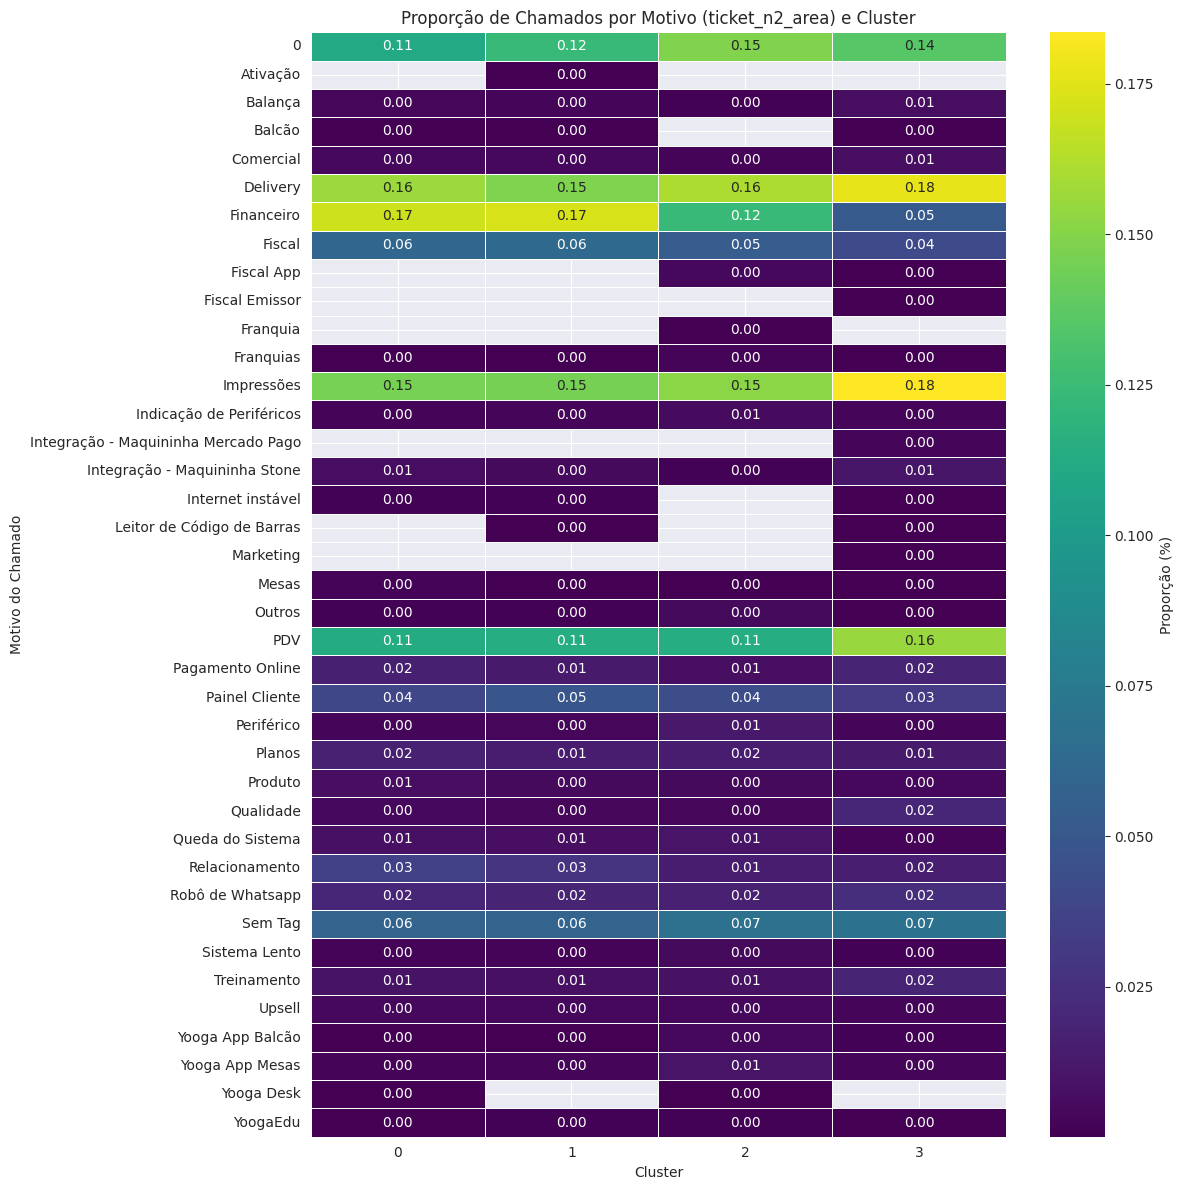

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar por Cluster e ticket_n1_model
df_agg_motivos = df.groupby(['Cluster', 'ticket_n2_area']).size().reset_index(name='qtd_chamados')

# 2. Calcular a proporção corretamente com transform()
df_agg_motivos['proporcao'] = df_agg_motivos['qtd_chamados'] / df_agg_motivos.groupby('Cluster')['qtd_chamados'].transform('sum')

# 3. Pivotar para formato de heatmap
df_heatmap = df_agg_motivos.pivot(index='ticket_n2_area', columns='Cluster', values='proporcao')

# 4. Plotar o heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(df_heatmap, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Proporção (%)'})
plt.title("Proporção de Chamados por Motivo (ticket_n2_area) e Cluster")
plt.ylabel("Motivo do Chamado")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()


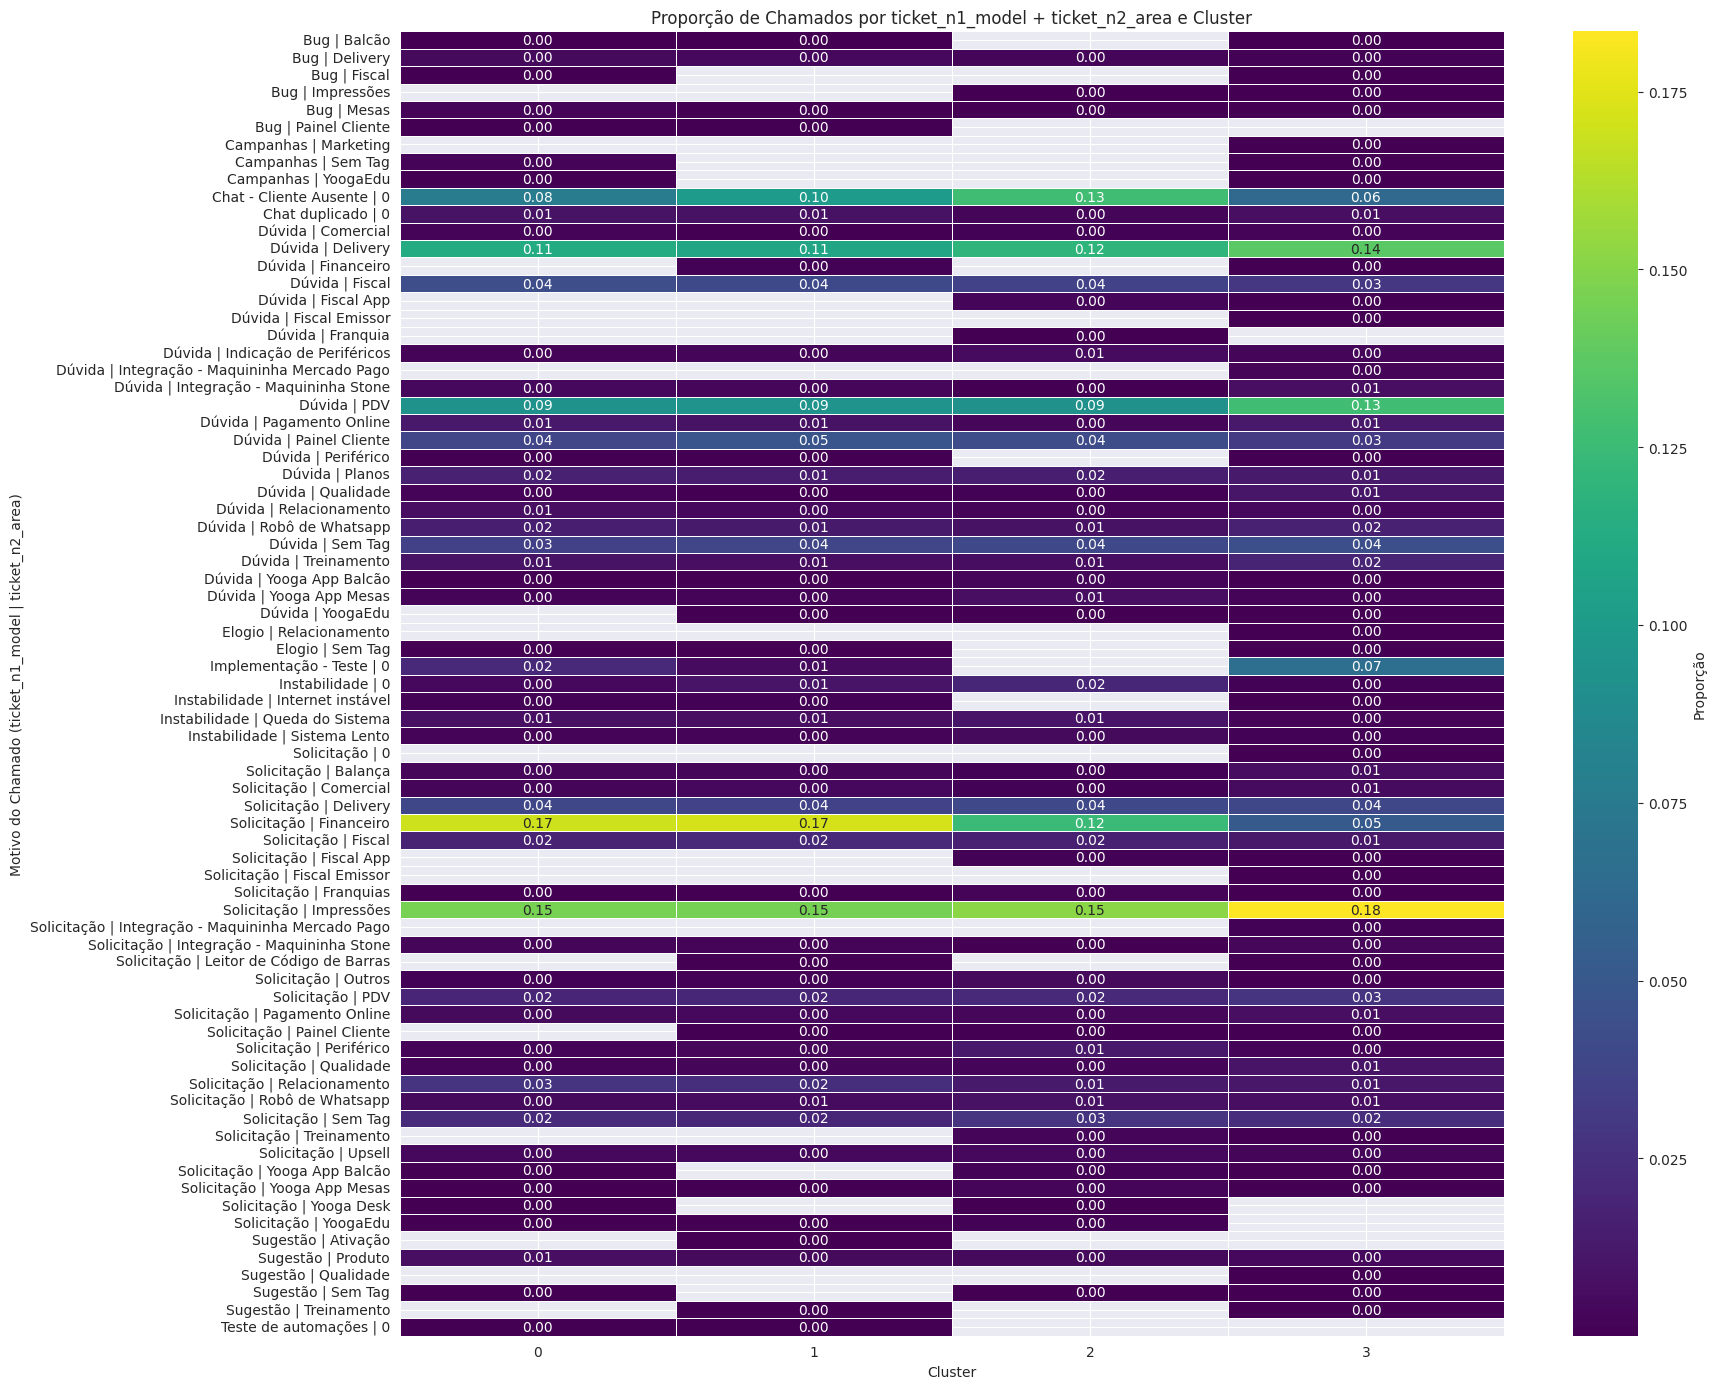

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Criar coluna combinando ticket_n1_model e ticket_n2_area
df['motivo_completo'] = df['ticket_n1_model'] + ' | ' + df['ticket_n2_area']

# 2. Agrupar por Cluster e motivo_completo
df_agg_motivos = df.groupby(['Cluster', 'motivo_completo']).size().reset_index(name='qtd_chamados')

# 3. Calcular proporção com transform()
df_agg_motivos['proporcao'] = df_agg_motivos['qtd_chamados'] / df_agg_motivos.groupby('Cluster')['qtd_chamados'].transform('sum')

# 4. Pivotar para formato de heatmap
df_heatmap = df_agg_motivos.pivot(index='motivo_completo', columns='Cluster', values='proporcao')

# 5. Plotar o heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(df_heatmap, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Proporção'})
plt.title("Proporção de Chamados por ticket_n1_model + ticket_n2_area e Cluster")
plt.ylabel("Motivo do Chamado (ticket_n1_model | ticket_n2_area)")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()


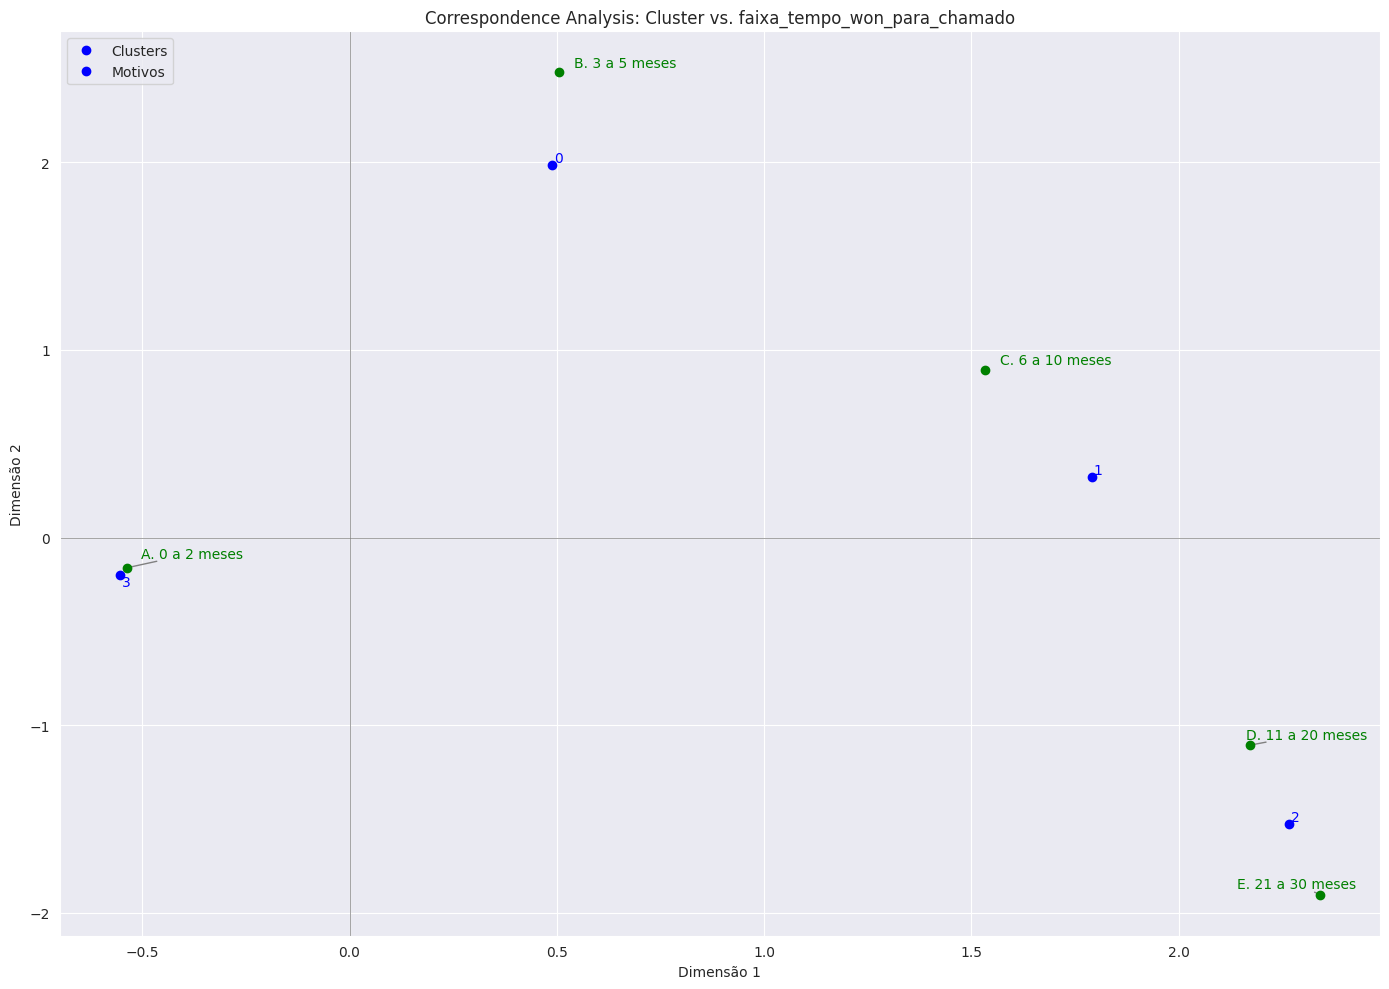

3

In [ ]:
import pandas as pd
import prince
import matplotlib.pyplot as plt

# 1. Tabela de contingência
contingencia = pd.crosstab(df['Cluster'], df['faixa_tempo_won_para_chamado'])

# 2. Aplicar Correspondence Analysis (CA)
ca = prince.CA(n_components=2, n_iter=5, engine='sklearn')
ca = ca.fit(contingencia)

from adjustText import adjust_text

# 3. Obter coordenadas
rows = ca.row_coordinates(contingencia)  # clusters
cols = ca.column_coordinates(contingencia)  # motivos

plt.figure(figsize=(14, 10))
texts = []

# 4. Plotar clusters (azul)
for i, (x, y) in rows.iterrows():
    plt.plot(x, y, 'bo')
    texts.append(plt.text(x, y, f"{i}", color='blue'))

# 5. Plotar motivos (verde)
for i, (x, y) in cols.iterrows():
    plt.plot(x, y, 'go')
    texts.append(plt.text(x, y, f"{i}", color='green'))

# 6. Ajustar automaticamente os textos
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray'))

plt.title("Correspondence Analysis: Cluster vs. faixa_tempo_won_para_chamado")
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(True)
plt.tight_layout()
plt.legend(['Clusters', 'Motivos'], loc='upper left')
plt.show()
3

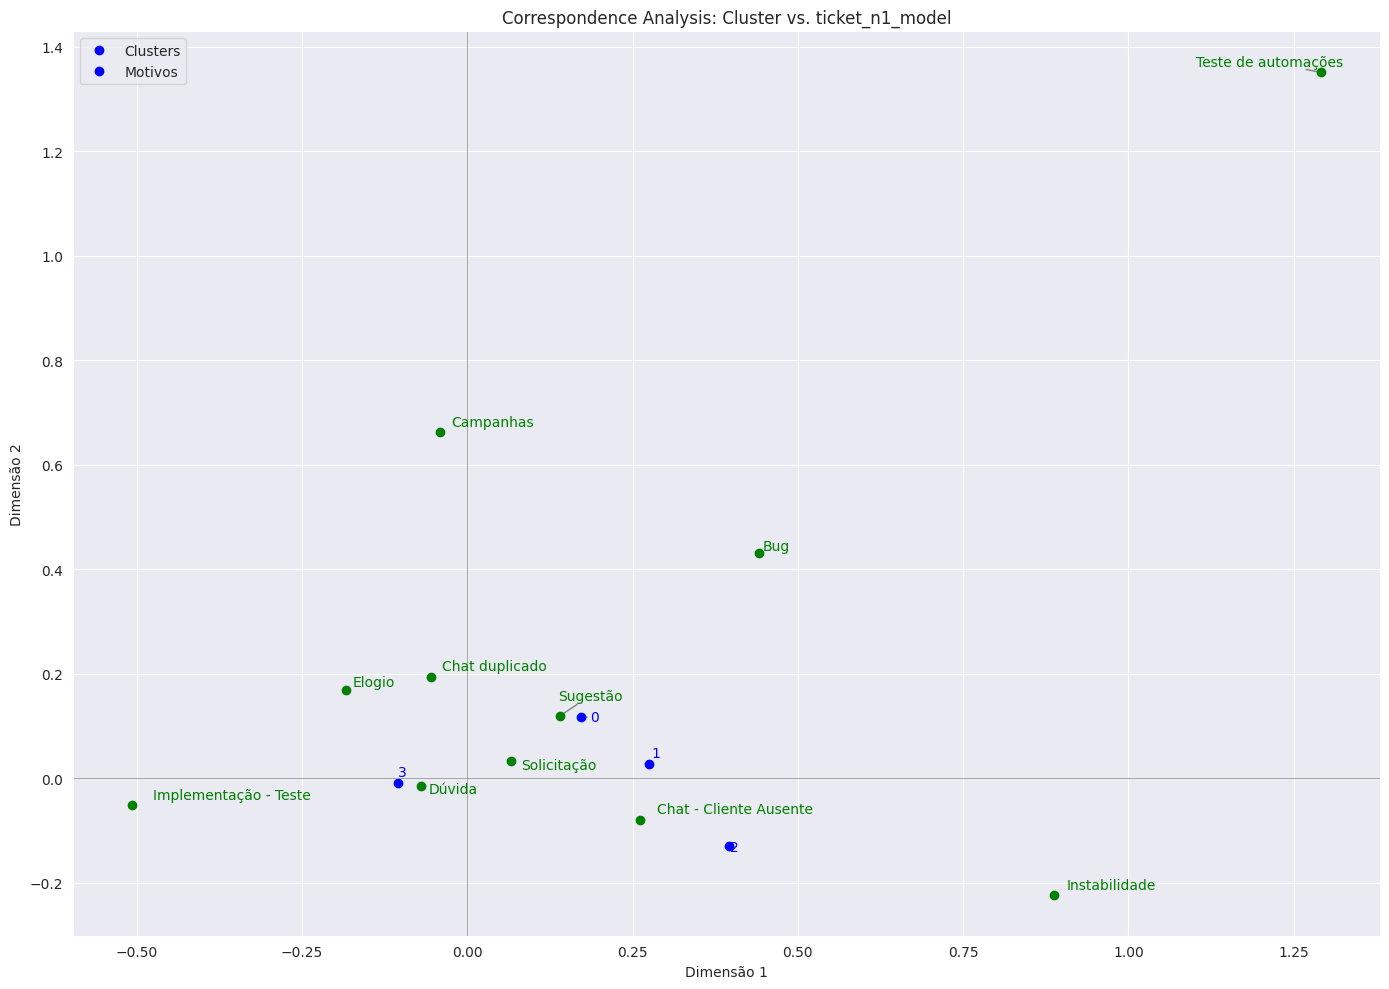

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


               precision    recall  f1-score   support

    A. 0 a 5k       0.24      0.99      0.39      1413
   B. 5 a 10k       0.20      0.00      0.00       606
  C. 10 a 15k       0.00      0.00      0.00       459
  D. 15 a 20k       1.00      0.00      0.01       323
  E. 20 a 25k       0.00      0.00      0.00       200
  F. 25 a 30k       0.00      0.00      0.00       189
  G. 30 a 50k       0.00      0.00      0.00       484
  H. 50 a 80k       0.00      0.00      0.00       329
 I. 80 a 100k       0.00      0.00      0.00       122
J. 100 a 150k       0.00      0.00      0.00       175
K. 150 a 200k       0.00      0.00      0.00       117
L. 200 a 250k       0.00      0.00      0.00       121
M. 250 a 400k       0.00      0.00      0.00       247
     N. 400k+       0.24      0.02      0.04       701
   sem vendas       0.00      0.00      0.00       467

     accuracy                           0.24      5953
    macro avg       0.11      0.07      0.03      5953
 weighte

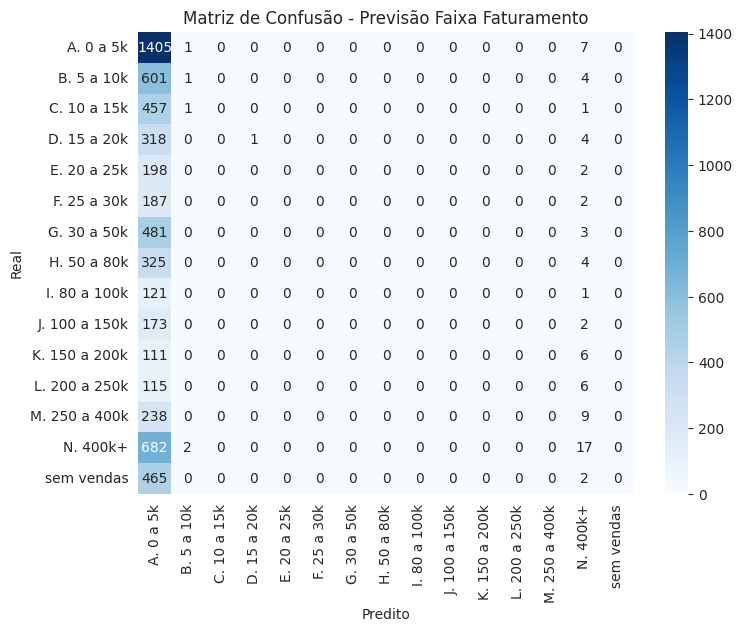

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar apenas as colunas relevantes
df_model = df[['faixa_faturamento', 'ticket_n1_model']].dropna()

# Encode das variáveis categóricas
le_faturamento = LabelEncoder()
le_ticket = LabelEncoder()
df_model['faixa_faturamento_encoded'] = le_faturamento.fit_transform(df_model['faixa_faturamento'])
df_model['ticket_n1_model_encoded'] = le_ticket.fit_transform(df_model['ticket_n1_model'])

# Separar features e target
X = df_model[['ticket_n1_model_encoded']]
y = df_model['faixa_faturamento_encoded']

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criar e treinar o modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Previsões
y_pred = rf.predict(X_test)

# Avaliação
print(classification_report(y_test, y_pred, target_names=le_faturamento.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le_faturamento.classes_, yticklabels=le_faturamento.classes_, cmap="Blues")
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Previsão Faixa Faturamento')
plt.show()

